# ST1504 CA2 Part A: CIFAR-10 Image Generation

## Objective

The objective of this project is to build and evaluate a generative deep learning model capable of generating CIFAR-10 images.

The CIFAR-10 dataset contains 60,000 colour images of size 32 × 32 pixels across 10 classes:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In this project, a Variational Autoencoder (VAE) / Generative Adversarial Network (GAN) will be trained to generate new images that resemble the original CIFAR-10 dataset.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [43]:
from tensorflow.keras.datasets import cifar10
import pickle
import numpy as np
import os

dataset_path = "cifar-10-batches-py"


def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels

In [44]:
x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    batch_path = os.path.join(
        dataset_path,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    x_train_batches.append(images)
    y_train_batches.append(labels)

x_train = np.concatenate(x_train_batches)
y_train = np.concatenate(y_train_batches)

x_test, y_test = load_cifar_batch(
    os.path.join(dataset_path, "test_batch")
)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


# Exploratory Data Analysis (EDA)

### Dataset Structure

The CIFAR-10 training dataset contains **50000 images**, while the testing dataset contains **50000 images**. Each image has dimensions of **32 × 32 pixels** with **3 colour channels**, representing red, green and blue (RGB).

The images are stored using the `uint8` datatype, with pixel intensities ranging from **0 to 255**. Therefore, the pixel values will need to be normalised before they are used to train the generative model.

In [45]:
# 1. Inspect the dataset structure
print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)

print("Image data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training image shape: (50000, 32, 32, 3)
Training label shape: (50000,)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


### Class distribution analysis

The class-distribution graph shows that each of the ten classes contains **5000 training images**. This means that the CIFAR-10 training dataset is equally balanced.

As no class is overrepresented or underrepresented, techniques such as oversampling or undersampling are not required. The balanced distribution should allow the model to learn from an equal number of examples from every class.

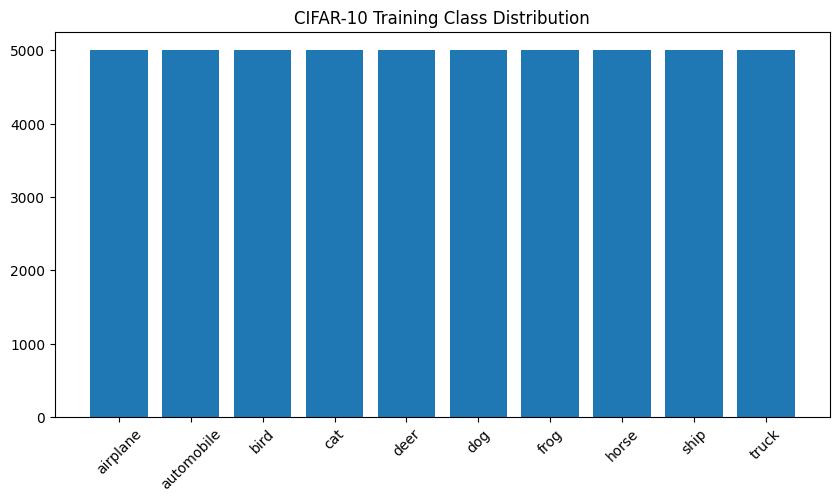

In [46]:
class_counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("CIFAR-10 Training Class Distribution")
plt.xticks(rotation=45)
plt.show()

### Visual Inspection of CIFAR-10 Images

A random sample of 25 training images was displayed to understand the visual characteristics of the dataset. The images contain considerable variation in backgrounds, positions and colours.

Although the objects are generally recognisable, their small resolution of **32 × 32 pixels** means that some details appear pixelated. This suggests that the generative model will need to learn the main shapes, colours and visual patterns of each class rather than fine details.



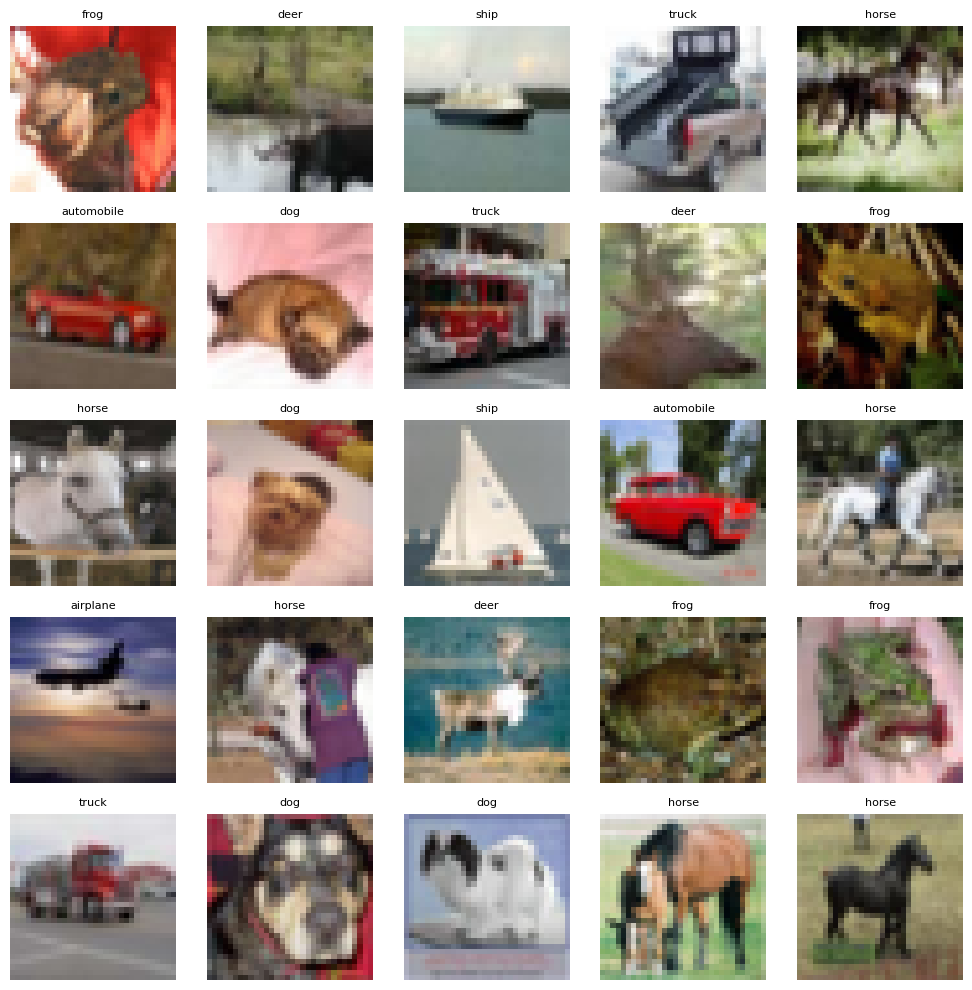

In [47]:
# 5x5 Grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(0, x_train.shape[0])
    ax.imshow(x_train[idx])
    ax.axis('off')
    ax.set_title(class_names[y_train[idx]], fontsize=8)
plt.tight_layout()
plt.show()

### Distribution of RGB Pixel Intensities

The histogram displays the distributions of pixel intensities for the red, green and blue channels. The three channels cover a wide range of intensity values and show overlapping distributions.

This confirms that colour information is an important feature of the dataset. Therefore, all three RGB channels will be retained instead of converting the images to grayscale for the main model.

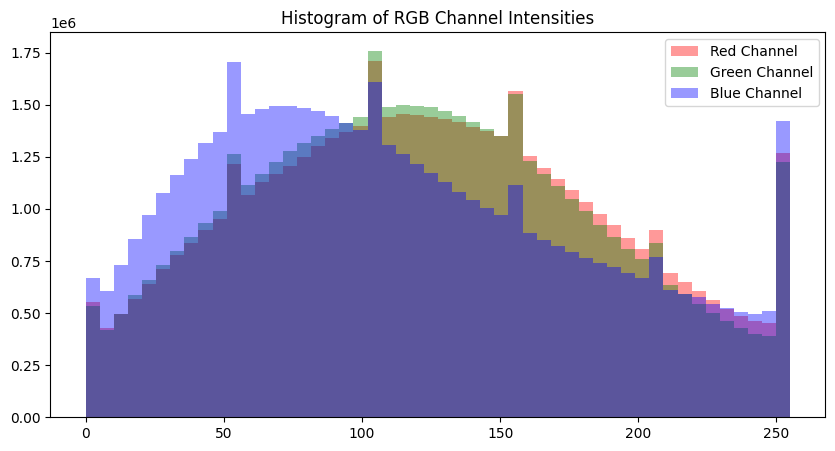

In [48]:
# RGB Histograms
plt.figure(figsize=(10, 5))
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(x_train[:, :, :, i].flatten(), bins=50, color=color, alpha=0.4, label=f'{color.capitalize()} Channel')
plt.title("Histogram of RGB Channel Intensities")
plt.legend()
plt.show()

### Data Cleaning 

The dataset was checked for missing and infinite pixel values. A total of **0 missing values** and **0 infinite values** were detected.

Therefore, no imputation or removal of images is required. The dataset can be retained in its original form before normalisation.

In [49]:
# Check for issues
print("Missing values:", np.isnan(x_train).sum())
print("Infinite values:", np.isinf(x_train).sum())


Missing values: 0
Infinite values: 0


### Normalization Checks
The original pixel values were converted from the range **[0, 255]** to **[-1, 1]**. This range is appropriate for a model whose final generator layer uses the tanh activation function.

The normalised histogram confirms that all transformed values fall within the expected range. The same transformation must later be applied consistently to both the training and testing datasets.

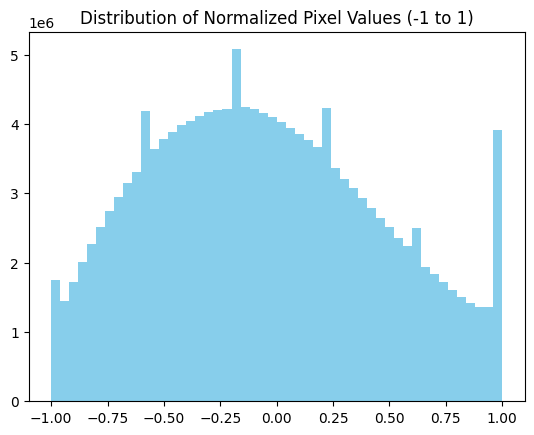

In [50]:
# Normalize and visualize
x_train_norm = (x_train.astype('float32') / 127.5) - 1
plt.hist(x_train_norm.flatten(), bins=50, color='skyblue')
plt.title("Distribution of Normalized Pixel Values (-1 to 1)")
plt.show()

### Variance Analysis (Inspection of Low-Contrast Images)

Pixel variance was calculated for each image to identify images with limited differences in colour or brightness. The five images with the lowest variance were then visually inspected.

The selected images appeared recognisable and mainly contained simple objects against relatively plain or uniform backgrounds. This shows that low pixel variance does not automatically indicate that an image is corrupted. Therefore, these images will be retained because they are still valid CIFAR-10 samples.

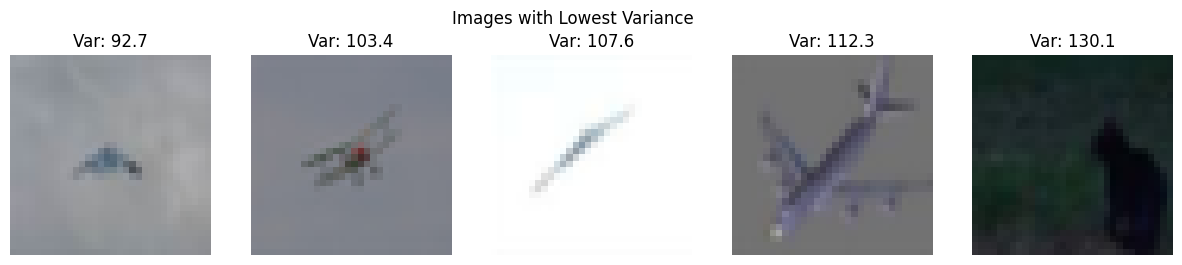

In [51]:
image_variances = x_train.var(axis=(1, 2, 3))
low_var_indices = np.argsort(image_variances)[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(low_var_indices):
    axes[i].imshow(x_train[idx])
    axes[i].set_title(f"Var: {image_variances[idx]:.1f}")
    axes[i].axis('off')
plt.suptitle("Images with Lowest Variance")
plt.show()

### Comparison of Training and Testing Distributions

Each class contains **5000 training samples** and **1000 testing samples**. Both datasets therefore have the same balanced class distribution.

This makes the testing set suitable for evaluating the model because its class composition is consistent with the training set. The testing images will be kept separate and will not be used for model training.

In [52]:
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
print("Training counts:", train_counts)
print("Test counts:", test_counts)

Training counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Average Within-Image Pixel Variance by Class

The graph compares the average within-image pixel variance across the ten CIFAR-10 classes. The truck class has the highest average variance, while the deer class has the lowest. A higher pixel variance indicates that images within the class generally contain greater differences in colour, brightness or contrast.

However, this measurement does not directly show that trucks are harder to generate than deer. The difficulty of generating each class will be evaluated later by visually inspecting the generated images and comparing class-specific evaluation results, such as manual acceptance rates and Fréchet Inception Distance (FID).

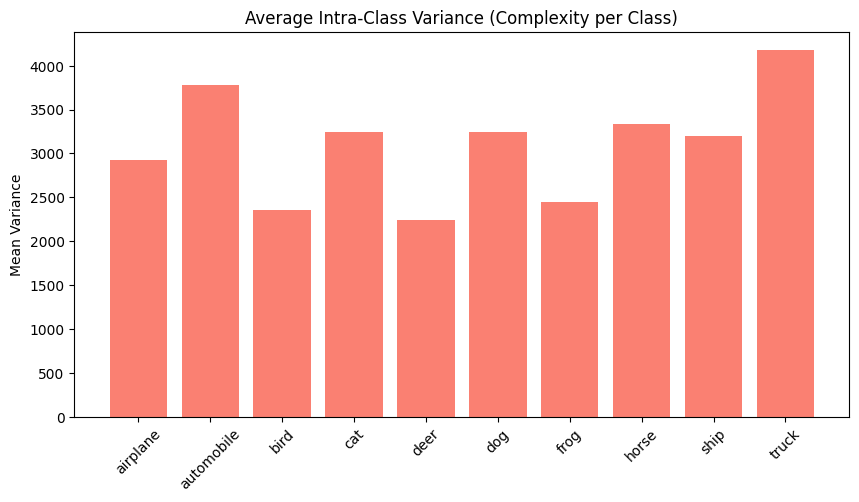

In [53]:
# Calculate variance for each image, then group by class
class_variances = []
for i in range(10):
    class_images = x_train[y_train == i]
    # Variance of each image, then mean of those variances
    avg_var = np.mean(np.var(class_images, axis=(1, 2, 3)))
    class_variances.append(avg_var)

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_variances, color='salmon')
plt.title("Average Intra-Class Variance (Complexity per Class)")
plt.ylabel("Mean Variance")
plt.xticks(rotation=45)
plt.show()

### Mean Image for Each Class

A mean image was created by averaging all the training images belonging to that trucks are harder to generate than deer. The difficulty of generating each class will be evaluated later by visually inspecting the generated images and comparing class each class. The resulting images show faint differences in the typical colours, backgrounds and object positions associated with each class. For example, the ship class generally has a blue-grey background, while vehicle classes such as automobiles and trucks contain darker areas around the lower-middle portion of the image.

However, all the mean images appear blurred because objects within the same class differ in position, size, colour, viewing angle and background. This demonstrates that there is considerable visual diversity within each class, which the generative model will need to learn.

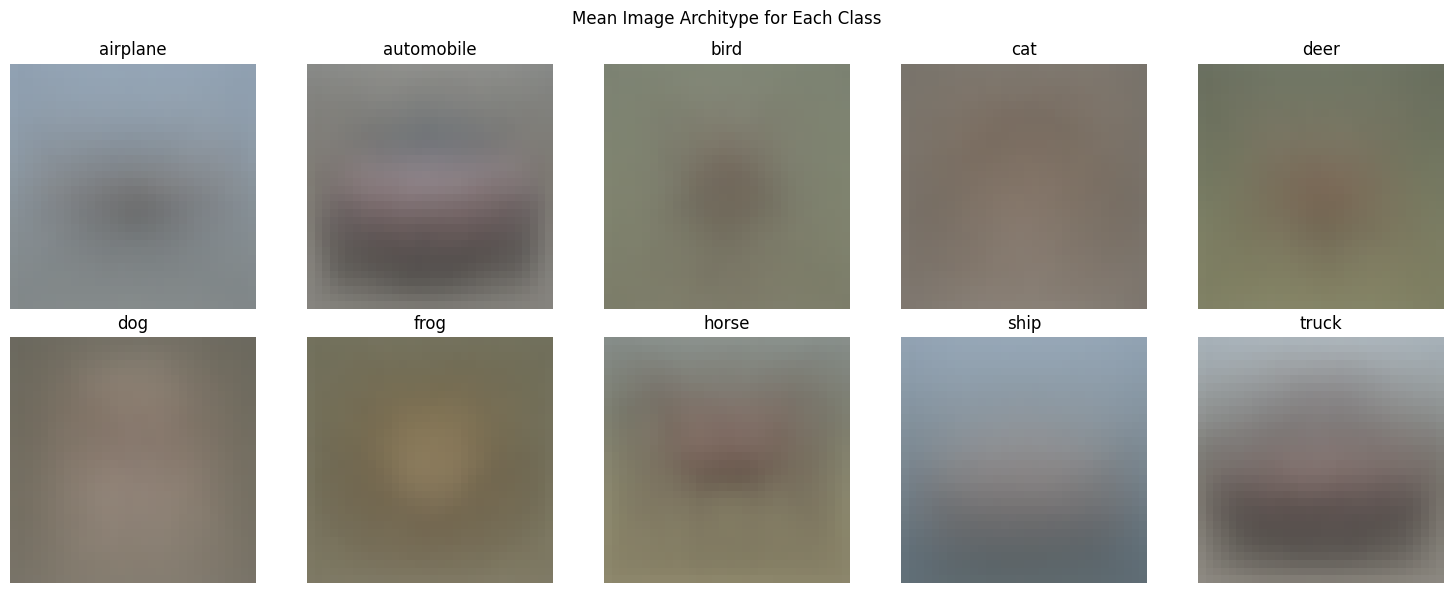

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    class_images = x_train[y_train == i]
    mean_img = np.mean(class_images, axis=0).astype('uint8')
    axes[i].imshow(mean_img)
    axes[i].set_title(class_names[i])
    axes[i].axis('off')

plt.suptitle("Mean Image Architype for Each Class")
plt.tight_layout()
plt.show()

### RGB and Grayscale Comparison

Converting an RGB image to grayscale reduces it from three colour channels to one channel and removes its colour information. Generating grayscale images may be easier because the model has fewer pixel values and colour relationships to learn. This may also reduce the model's computational requirements.

However, colour provides useful visual information for distinguishing certain objects and backgrounds. Removing colour could make some generated objects less recognisable even if their overall shapes are preserved. Since the main task involves generating coloured CIFAR-10 images, RGB images will be retained for model training. Grayscale generation could instead be investigated as a separate experiment.

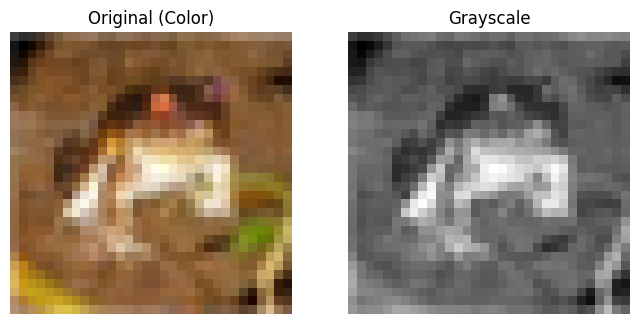

In [55]:
# Convert to grayscale by averaging channels
x_train_gray = np.mean(x_train, axis=3, keepdims=True)

# Compare shapes and visualize
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_train[0])
plt.title("Original (Color)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_train_gray[0].reshape(32, 32), cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

### Image-Shape Consistency

All training images were found to have the same dimensions of 32 × 32 × 3. No malformed images or inconsistent image dimensions were detected.

Therefore, resizing, cropping and padding are not required before model training. Maintaining the original dimensions also ensures that no visual information is unnecessarily removed or distorted.

In [56]:
# Check for consistent image shapes
shapes = [img.shape for img in x_train]
unique_shapes = np.unique(shapes, axis=0)

if len(unique_shapes) == 1:
    print(f"All images have a consistent shape of: {unique_shapes[0]}")
else:
    print("Warning: Dataset contains inconsistent image shapes:", unique_shapes)

All images have a consistent shape of: [32 32  3]
